In [2]:
import pandas as pd
import os
import numpy as np

In [3]:
year=2011

In [4]:
nis_path = f'data/NIS{year}_Village_Year_Coords.xlsx'
nis = pd.read_excel(nis_path)
nis.head()

,VillGis,Province,District,Commune,Village,XPHUM,YPHUM,Year,1-FAMILY,3-MAL_TOT,...,1449-T_Fe_Por_6-11,1450-Souy_Fami,1451-T_Soury_Indig,1452-T_Fe_Soury_Indig,1453-T_Soury_6-11,1454-T_Fe_Soury_6-11,1455-T_Oth_Indig,1456-T_Fe_Oth_Indig,1457-T_Oth_6-11,1458-T_Fe_Oth_6-11
0,1020101,Banteay Meanchey,Mongkol Borei,Banteay Neang,Ou Thum,287800.0,1494700.0,2011,150.0,207.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1020102,Banteay Meanchey,Mongkol Borei,Banteay Neang,Phnum,285900.0,1494700.0,2011,280.0,598.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1020103,Banteay Meanchey,Mongkol Borei,Banteay Neang,Banteay Neang,285900.0,1494300.0,2011,384.0,942.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1020104,Banteay Meanchey,Mongkol Borei,Banteay Neang,Kouk Pnov,284900.0,1493500.0,2011,216.0,475.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1020105,Banteay Meanchey,Mongkol Borei,Banteay Neang,Trang,285000.0,1494100.0,2011,185.0,479.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
#Total population per village
nis["511-POP"] = nis["3-MAL_TOT"] + nis["2-FEM_TOT"]
nis.head()

,VillGis,Province,District,Commune,Village,XPHUM,YPHUM,Year,1-FAMILY,3-MAL_TOT,...,1450-Souy_Fami,1451-T_Soury_Indig,1452-T_Fe_Soury_Indig,1453-T_Soury_6-11,1454-T_Fe_Soury_6-11,1455-T_Oth_Indig,1456-T_Fe_Oth_Indig,1457-T_Oth_6-11,1458-T_Fe_Oth_6-11,511-POP
0,1020101,Banteay Meanchey,Mongkol Borei,Banteay Neang,Ou Thum,287800.0,1494700.0,2011,150.0,207.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,457.0
1,1020102,Banteay Meanchey,Mongkol Borei,Banteay Neang,Phnum,285900.0,1494700.0,2011,280.0,598.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1255.0
2,1020103,Banteay Meanchey,Mongkol Borei,Banteay Neang,Banteay Neang,285900.0,1494300.0,2011,384.0,942.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2004.0
3,1020104,Banteay Meanchey,Mongkol Borei,Banteay Neang,Kouk Pnov,284900.0,1493500.0,2011,216.0,475.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,942.0
4,1020105,Banteay Meanchey,Mongkol Borei,Banteay Neang,Trang,285000.0,1494100.0,2011,185.0,479.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,914.0


## Education module

In [6]:
#Illiterate population per village (women and men among 15 and 45 years)
nis["512-ILLITERATE_POP"] = nis["74-M_ILT15_17"] + nis["241-M_ILT18_24"]+nis["243-M_ILT25_35"]+nis["245-M_ILT36_45"] + nis["79-F_ILT15_17"]+nis["242-F_ILT18_24"]+nis["244-F_ILT25_35"]+nis["246-F_ILT36_45"]
nis["512-ILLITERATE_POP"].describe()

count    14043.000000
mean        43.106957
std         72.646019
min          0.000000
25%          0.000000
50%         18.000000
75%         53.000000
max       2537.000000
Name: 512-ILLITERATE_POP, dtype: float64

In [7]:
#Illiterate population rate per village
nis["513-ILLITERATE_RATE"] = (nis["512-ILLITERATE_POP"]/nis["511-POP"])*100
nis["511-POP"].describe()

#Comments: Literacy rate for youth and adult population is 91% and 86% in 2016 (https://uis.unesco.org/sites/default/files/documents/fs45-literacy-rates-continue-rise-generation-to-next-en-2017_0.pdf)
    #So there's two options: take the mean of adult and youth (11.5%) and take it as the threshold criteria for deprivation or divide it for age groups

count    14043.000000
mean      1034.878374
std        887.559560
min          0.000000
25%        542.000000
50%        821.000000
75%       1236.000000
max      22525.000000
Name: 511-POP, dtype: float64

In [8]:
print((nis["513-ILLITERATE_RATE"] == 0).sum())
print(nis["513-ILLITERATE_RATE"].isna().sum())

3637
33


## Health
### Child mortality

In [9]:
#Child mortality rate must be below 3.8%, the global rate between 2000-2015. Source:https://data.unicef.org/topic/child-survival/under-five-mortality/#:~:text=The%20global%20under%2Dfive%20mortality,a%20matter%20of%20urgent%20concern.

#Child mortality rate per village

nis["522-POB_UD5yrs"]=nis["201-MAL_0_2"]+nis["202-FEM_0_5"]+nis["203-MAL_3_4"]+nis["204-FEM_3_4"]+nis["205-MAL_5"]+nis["206-FEM_5"]
nis["523-C_MORT_RATE"]=nis["373-TOT_UD5_die"]/nis["522-POB_UD5yrs"]*100
pd.set_option("display.float_format", "{:.6f}".format)

nis["523-C_MORT_RATE"].describe()

count   14040.000000
mean        0.267822
std         2.122087
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        97.701149
Name: 523-C_MORT_RATE, dtype: float64

In [10]:
print((nis["366-KM_Heal_cent"] == 0).sum())
print(nis["366-KM_Heal_cent"].isna().sum())

942
30


## Living standards module
### Drinking water

In [11]:
#The deprivation threshold criteria will be under 71% (average between 69 and 73, data of 2015 and 2022 data), in which the village has less than a 71% of families with improved sources of water rate, it's considered deprived
    #Source: https://sdgs.un.org/goals/goal6#progress_and_info


#Source of drinking water is improved (purified systems, pump, mixed wells) or unimproved (pond, river, lakes, natural ponds, etc)

nis["514-IMPROV_WAT"] = nis["391-Wat_pur"] + nis["392-Wat_well"]
#Family responses related to source of drinking water 
nis["524-Fam_Wat_Res"]=nis["391-Wat_pur"] + nis["392-Wat_well"]+nis["394-Wat_pond"] + nis["396-Wat_river"]

#Rate of families with improved water 
nis["515-IMPROV_WAT_RATE"]=nis["514-IMPROV_WAT"]/nis["1-FAMILY"]*100
nis["516-UNIMPROV_WAT"] = nis["394-Wat_pond"] + nis["1-FAMILY"]

#Rate of families with unimproved water 
nis["517-UNIMPROV_WAT_RATE"]=nis["516-UNIMPROV_WAT"]/nis["1-FAMILY"]*100
nis.head()

,VillGis,Province,District,Commune,Village,XPHUM,YPHUM,Year,1-FAMILY,3-MAL_TOT,...,511-POP,512-ILLITERATE_POP,513-ILLITERATE_RATE,522-POB_UD5yrs,523-C_MORT_RATE,514-IMPROV_WAT,524-Fam_Wat_Res,515-IMPROV_WAT_RATE,516-UNIMPROV_WAT,517-UNIMPROV_WAT_RATE
0,1020101,Banteay Meanchey,Mongkol Borei,Banteay Neang,Ou Thum,287800.000000,1494700.000000,2011,150.000000,207.000000,...,457.000000,13.000000,2.844639,112.000000,0.000000,0.000000,150.000000,0.000000,300.000000,200.000000
1,1020102,Banteay Meanchey,Mongkol Borei,Banteay Neang,Phnum,285900.000000,1494700.000000,2011,280.000000,598.000000,...,1255.000000,14.000000,1.115538,146.000000,4.109589,1.000000,265.000000,0.357143,541.000000,193.214286
2,1020103,Banteay Meanchey,Mongkol Borei,Banteay Neang,Banteay Neang,285900.000000,1494300.000000,2011,384.000000,942.000000,...,2004.000000,0.000000,0.000000,199.000000,0.000000,106.000000,364.000000,27.604167,410.000000,106.770833
3,1020104,Banteay Meanchey,Mongkol Borei,Banteay Neang,Kouk Pnov,284900.000000,1493500.000000,2011,216.000000,475.000000,...,942.000000,0.000000,0.000000,101.000000,0.000000,6.000000,200.000000,2.777778,222.000000,102.777778
4,1020105,Banteay Meanchey,Mongkol Borei,Banteay Neang,Trang,285000.000000,1494100.000000,2011,185.000000,479.000000,...,914.000000,0.000000,0.000000,147.000000,0.000000,85.000000,168.000000,45.945946,206.000000,111.351351


In [12]:
print((nis["514-IMPROV_WAT"] == 0).sum())
print(nis["514-IMPROV_WAT"].isna().sum())

2315
30


In [13]:
print((nis["515-IMPROV_WAT_RATE"] == 0).sum())
print(nis["515-IMPROV_WAT_RATE"].isna().sum())

2312
33


In [14]:
nis["515-IMPROV_WAT_RATE"].describe()

count   14040.000000
mean       53.872548
std        39.614030
min         0.000000
25%        11.506706
50%        55.642624
75%        99.523521
max       100.000000
Name: 515-IMPROV_WAT_RATE, dtype: float64

In [83]:
#Creating dummy for variable of unimproved source of water (517-FAM_UNIMPROV_WAT_RATE)
    # takes the value of 1 if more than 50% of the families have an unimproved sources of water

#nis["525-UNIMPROV_WAT_DUM"] = (nis["517-FAM_UNIMPROV_WAT_RATE"] >= 50).astype(int)
#nis["525-UNIMPROV_WAT_DUM"].describe()

### Electricity

In [15]:
#Global electricity access in 2022 is 91% (https://sdgs.un.org/goals/goal7#progress_and_info)

#Rate of houses that have electricity
nis["528-Elec_Rate"]=nis["330-Villa_R_Elec"] / nis["1-FAMILY"]*100

nis.describe()

,VillGis,XPHUM,YPHUM,Year,1-FAMILY,3-MAL_TOT,2-FEM_TOT,73-F_HHH,201-MAL_0_2,202-FEM_0_5,...,512-ILLITERATE_POP,513-ILLITERATE_RATE,522-POB_UD5yrs,523-C_MORT_RATE,514-IMPROV_WAT,524-Fam_Wat_Res,515-IMPROV_WAT_RATE,516-UNIMPROV_WAT,517-UNIMPROV_WAT_RATE,528-Elec_Rate
count,14073.000000,13083.000000,13083.000000,14073.000000,14043.000000,14043.000000,14043.000000,14043.000000,14043.000000,14043.000000,...,14043.000000,14040.000000,14043.000000,14040.000000,14043.000000,14043.000000,14040.000000,14043.000000,14040.000000,14040.000000
mean,10194822.496909,472110.685164,1334154.623557,2011.000000,216.153386,505.914335,528.964039,32.748914,24.023357,24.176387,...,43.106957,4.786126,129.832799,0.267822,121.092502,173.173752,53.872548,239.832301,112.682171,0.212709
std,6698178.742679,100307.895825,105075.131675,0.000000,178.540811,428.153454,470.689085,35.793264,22.051054,24.675161,...,72.646019,6.920760,117.648708,2.122087,165.080125,174.390902,39.614030,195.640016,26.763690,2.141888
min,1020101.000000,213079.000000,1152671.000000,2011.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000
25%,4060309.000000,427275.000000,1252121.500000,2011.000000,114.000000,264.000000,276.000000,13.000000,11.000000,11.000000,...,0.000000,0.000000,64.000000,0.000000,18.000000,75.000000,11.506706,125.000000,100.000000,0.000000
50%,8090113.000000,476292.000000,1306276.000000,2011.000000,173.000000,400.000000,420.000000,24.000000,19.000000,19.000000,...,18.000000,2.161773,102.000000,0.000000,83.000000,134.000000,55.642624,189.000000,100.000000,0.000000
75%,16030201.000000,536482.000000,1416889.500000,2011.000000,263.000000,607.000000,631.000000,40.000000,30.000000,30.000000,...,53.000000,6.194690,159.000000,0.000000,166.000000,219.000000,99.523521,293.000000,107.725207,0.000000
max,24020406.000000,770884.000000,1594700.000000,2011.000000,5133.000000,10632.000000,15347.000000,733.000000,465.000000,1151.000000,...,2537.000000,56.588072,3138.000000,97.701149,5133.000000,5133.000000,100.000000,5133.000000,200.000000,94.495413


In [86]:
#Creating a dummy for village houses with electricity (330-Villa_R_Elec), 
    # takes the value of 1 if none village houses has electricity

#nis["330-Villa_R_Elec"].describe()
#nis["523-Elec_DUM"]= (nis["330-Villa_R_Elec"] == 0).astype(int)
 

### Housing quality (roof)

In [16]:
#Materials of roof are High Quality (tiled and zinc or fibro) or Low Quality (Thatched) among houses that have electricity
nis["518-HQ_ROOF"]=nis["326-Z_Fib_R_Elec"] + nis["327-Til_R_Elec"]

#Total of roof materials 
nis["525-TOT_ROOF"]=nis["326-Z_Fib_R_Elec"] + nis["327-Til_R_Elec"]+nis["325-THAT_R_Elec"]

#Rate of High Quality (HQ) roofs 
# nis["519-HQ_ROOF_RATE"]=nis["518-HQ_ROOF"] / nis["525-TOT_ROOF"]*100

#Rate of Low Quality (LQ) roofs 
# nis["526-LQ_ROOF_RATE"]=nis["325-THAT_R_Elec"] / nis["525-TOT_ROOF"]*100

#Only about 66% of housing units are built with durable material for roof, wall, or floor (p. 19 - https://documents1.worldbank.org/curated/en/370141635794493951/pdf/Introducing-the-Adequate-Housing-Index-AHI-A-New-Approach-to-Estimate-the-Adequate-Housing-Deficit-within-and-across-Emerging-Economies.pdf)
# And electricity access is 91% https://sdgs.un.org/goals/goal7#progress_and_info

#Rate of High Quality (HQ) roofs with electricity
nis["533-HQ_ROOF_ELEC_RATE"]=(nis["518-HQ_ROOF"] / nis["1-FAMILY"])*100
nis["534-LQ_ROOF_ELEC_RATE"]=(nis["325-THAT_R_Elec"] / nis["1-FAMILY"])*100

nis["534-LQ_ROOF_ELEC_RATE"].describe()

count   14040.000000
mean        0.719718
std         3.385834
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        75.423729
Name: 534-LQ_ROOF_ELEC_RATE, dtype: float64

In [17]:
print((nis["533-HQ_ROOF_ELEC_RATE"] == 0).sum())
print(nis["533-HQ_ROOF_ELEC_RATE"].isna().sum())

7808
33


In [18]:
nis["1-FAMILY"].describe()

count   14043.000000
mean      216.153386
std       178.540811
min         0.000000
25%       114.000000
50%       173.000000
75%       263.000000
max      5133.000000
Name: 1-FAMILY, dtype: float64

In [91]:
#Creating dummy for variable of low quality materials of roof (526-LQ_ROOF)
    # takes the value of 1 if more than 50% of the families have roof with low quality materials
#nis["527-LQ_ROOF_DUM"] = (nis["526-LQ_ROOF"] >= 50).astype(int)

#nis["527-LQ_ROOF_DUM"].describe()

### Assets ownership

In [19]:
#### Mobility assets 
    #Assets considered by NIS (moto and motor tri-cycle) 
nis["520-MOB_ASSETS"] = nis["30-MOTO_NUM"] + nis["355-Mot_Tricyc_NUM"]
nis["521-MOB_ASSETS_RATE"]=nis["520-MOB_ASSETS"]/nis["511-POP"]*100

#Families that own an cultivated land
nis["529-CULT_LAND"] = nis["1-FAMILY"] - nis["289-No_F_Land"]

### Agricultural assets (number of families that have irrigation wells, pigs, goat/sheep, chicken, duck, crocodiles, own cultivated land). 
nis["530-AGRI_ASSETS"] = nis["529-CULT_LAND"] + nis["282-Own_IRRI_Wells"]+nis["297-Goat_fami"]+nis["299-Chick_fami"]+nis["302-Duck_fami"]+nis["316-Croco_fami"]
nis["531-AGRI_ASSETS_RATE"]=nis["530-AGRI_ASSETS"]/nis["1-FAMILY"]*100
        #Revisar  
nis["531-AGRI_ASSETS_RATE"].describe()


count   14040.000000
mean      163.123676
std        52.963729
min         0.000000
25%       115.404373
50%       174.304988
75%       200.000000
max       364.015152
Name: 531-AGRI_ASSETS_RATE, dtype: float64

In [20]:
print((nis["521-MOB_ASSETS_RATE"] == 0).sum())
print(nis["521-MOB_ASSETS_RATE"].isna().sum())

105
33


In [21]:

nis["521-MOB_ASSETS_RATE"].describe()

count   14040.000000
mean       10.418854
std         6.429730
min         0.000000
25%         6.231398
50%         9.273183
75%        13.443154
max       190.410959
Name: 521-MOB_ASSETS_RATE, dtype: float64

### Sanitation

In [22]:
#Rate of houses that have latrines
nis["532-Sanit_Rate"]=100-(nis["23-TOILET"] / nis["1-FAMILY"]*100)
nis.head()

,VillGis,Province,District,Commune,Village,XPHUM,YPHUM,Year,1-FAMILY,3-MAL_TOT,...,518-HQ_ROOF,525-TOT_ROOF,533-HQ_ROOF_ELEC_RATE,534-LQ_ROOF_ELEC_RATE,520-MOB_ASSETS,521-MOB_ASSETS_RATE,529-CULT_LAND,530-AGRI_ASSETS,531-AGRI_ASSETS_RATE,532-Sanit_Rate
0,1020101,Banteay Meanchey,Mongkol Borei,Banteay Neang,Ou Thum,287800.000000,1494700.000000,2011,150.000000,207.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,150.000000,100.000000,100.000000
1,1020102,Banteay Meanchey,Mongkol Borei,Banteay Neang,Phnum,285900.000000,1494700.000000,2011,280.000000,598.000000,...,235.000000,238.000000,83.928571,1.071429,118.000000,9.402390,270.000000,304.000000,108.571429,44.642857
2,1020103,Banteay Meanchey,Mongkol Borei,Banteay Neang,Banteay Neang,285900.000000,1494300.000000,2011,384.000000,942.000000,...,155.000000,155.000000,40.364583,0.000000,175.000000,8.732535,384.000000,693.000000,180.468750,55.729167
3,1020104,Banteay Meanchey,Mongkol Borei,Banteay Neang,Kouk Pnov,284900.000000,1493500.000000,2011,216.000000,475.000000,...,32.000000,52.000000,14.814815,9.259259,93.000000,9.872611,186.000000,190.000000,87.962963,56.018519
4,1020105,Banteay Meanchey,Mongkol Borei,Banteay Neang,Trang,285000.000000,1494100.000000,2011,185.000000,479.000000,...,116.000000,116.000000,62.702703,0.000000,76.000000,8.315098,185.000000,185.000000,100.000000,0.000000


In [23]:
print((nis["532-Sanit_Rate"] == 0).sum())
print(nis["532-Sanit_Rate"].isna().sum())

998
33


In [24]:
nis["532-Sanit_Rate"].describe()

count   14040.000000
mean       65.116719
std        31.653823
min         0.000000
25%        44.520548
50%        76.190476
75%        91.071429
max       100.000000
Name: 532-Sanit_Rate, dtype: float64

In [33]:
#The year needs to be change
file_path=f"data/NISAddRates_{year}.xlsx"
nis.to_excel(file_path, index=False)

In [25]:
nis["513-ILLITERATE_RATE"].describe()

count   14040.000000
mean        4.786126
std         6.920760
min         0.000000
25%         0.000000
50%         2.161773
75%         6.194690
max        56.588072
Name: 513-ILLITERATE_RATE, dtype: float64

In [26]:
nis["523-C_MORT_RATE"].describe()

count   14040.000000
mean        0.267822
std         2.122087
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        97.701149
Name: 523-C_MORT_RATE, dtype: float64

In [27]:
nis["373-TOT_UD5_die"].describe()

count   14043.000000
mean        0.278359
std         2.078452
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       131.000000
Name: 373-TOT_UD5_die, dtype: float64

In [28]:
pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 

print(nis.isna().sum())

VillGis                           0
Province                          0
District                          0
Commune                           0
Village                           0
XPHUM                           990
YPHUM                           990
Year                              0
1-FAMILY                         30
3-MAL_TOT                        30
2-FEM_TOT                        30
73-F_HHH                         30
201-MAL_0_2                      30
202-FEM_0_5                      30
203-MAL_3_4                      30
204-FEM_3_4                      30
205-MAL_5                        30
206-FEM_5                        30
207-MAL_6                        30
208-FEM_6                        30
209-MAL_7_11                     30
210-FEM_7_11                     30
211-MAL_12_14                    30
212-FEM_12_14                    30
213-MAL_15_17                    30
214-FEM_15_17                    30
215-MAL_18_24                    30
216-FEM_18_24               

<Axes: >

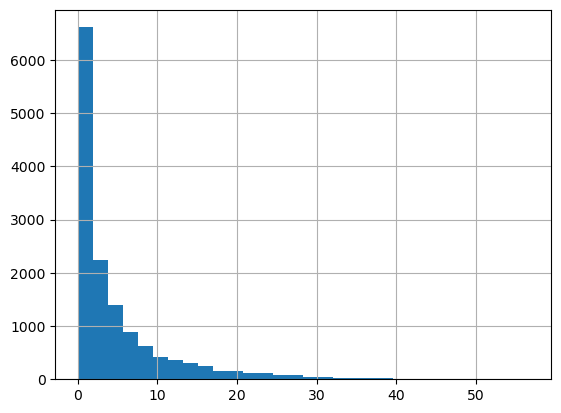

In [29]:
nis = nis[nis["513-ILLITERATE_RATE"].notna()]  # Elimina NaN
nis = nis[nis["513-ILLITERATE_RATE"] != np.inf] 
nis["513-ILLITERATE_RATE"].hist(bins=30)